In [126]:
# Import thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt

# Đọc file dữ liệu đã xử lý
df = pd.read_csv("credit_risk_dataset_5c.csv")

# Xem nhanh dữ liệu
print("Shape:", df.shape)
df.head()

Shape: (1277409, 12)


,pub_rec,num_tl_90g_dpd_24m,annual_inc,dti,loan_amnt,term,tot_cur_bal,home_ownership,purpose,verification_status,addr_state,label
0,0.0,0.0,55000.0,5.91,3600.0,36 months,144904.0,MORTGAGE,debt_consolidation,Not Verified,PA,0
1,0.0,0.0,65000.0,16.06,24700.0,36 months,204396.0,MORTGAGE,small_business,Not Verified,SD,0
2,0.0,0.0,63000.0,10.78,20000.0,60 months,189699.0,MORTGAGE,home_improvement,Not Verified,IL,0
3,0.0,0.0,104433.0,25.37,10400.0,60 months,331730.0,MORTGAGE,major_purchase,Source Verified,PA,0
4,0.0,0.0,34000.0,10.20,11950.0,36 months,12798.0,RENT,debt_consolidation,Source Verified,GA,0


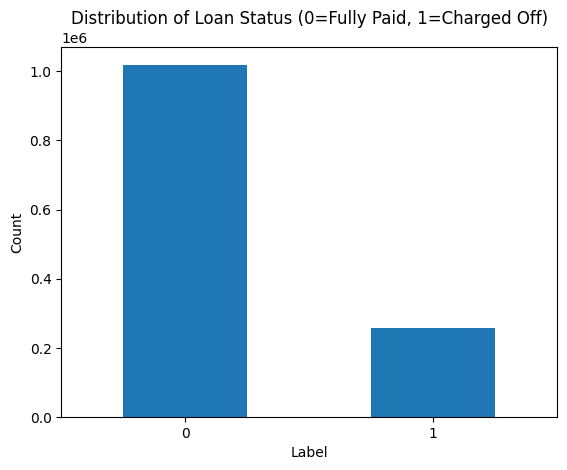

In [127]:
# Kiểm tra phân bố nhãn (có bị lệch hay không)
plt.figure()
df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Loan Status (0=Fully Paid, 1=Charged Off)")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks(rotation=0, ha='center')

plt.show()

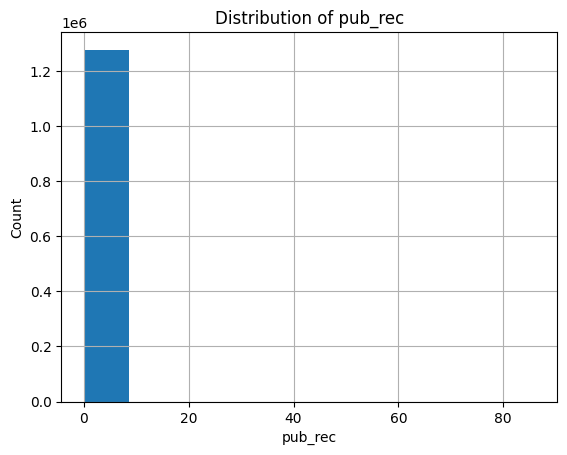

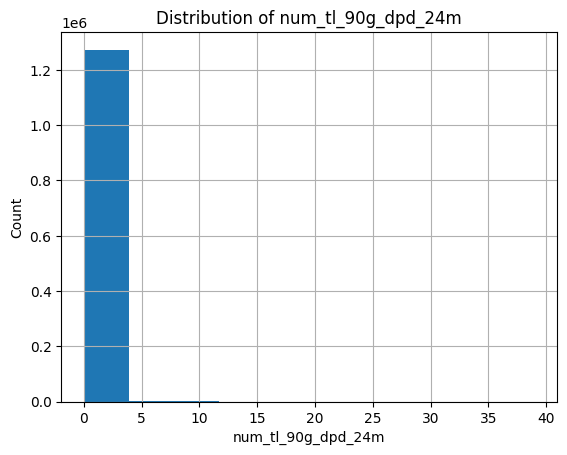

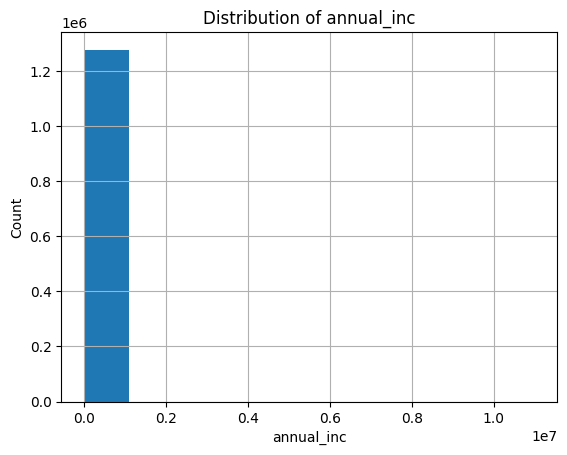

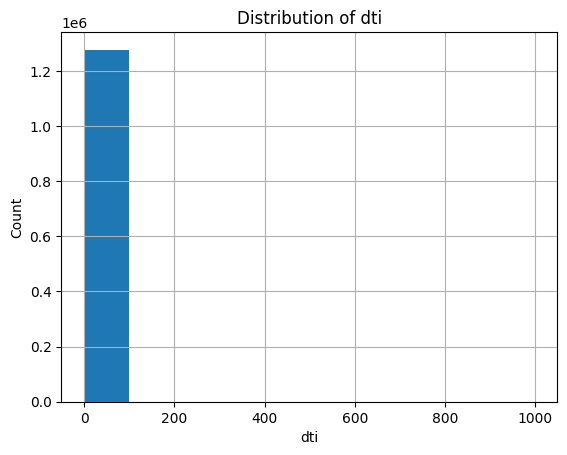

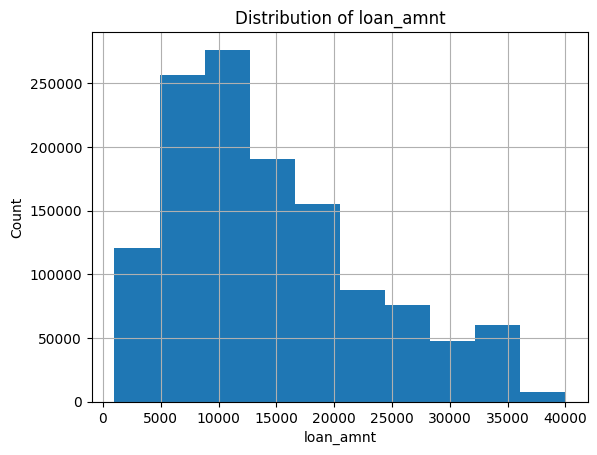

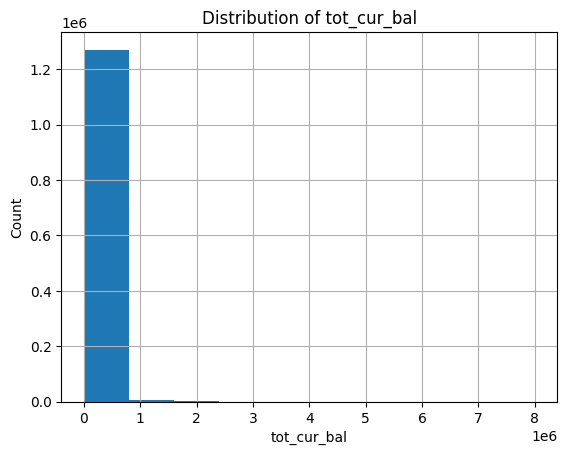

max value of annual_inc: 10999200.0
max value of tot_cur_bal: 8000078.0


In [128]:
# Danh sách các biến số
numeric_cols = ["pub_rec","num_tl_90g_dpd_24m","annual_inc", "dti", "loan_amnt", "tot_cur_bal"]

# Vẽ histogram cho từng biến
for col in numeric_cols:
    plt.figure()
    df[col].hist()

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()


print("max value of annual_inc:", df["annual_inc"].max())
print("max value of tot_cur_bal:", df["tot_cur_bal"].max())

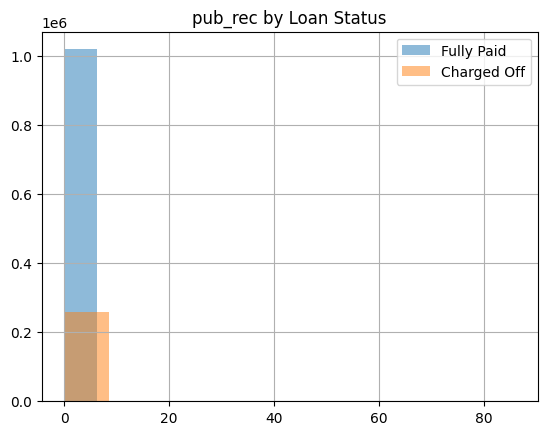

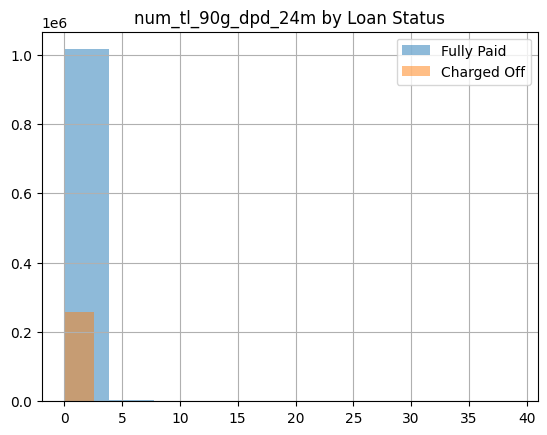

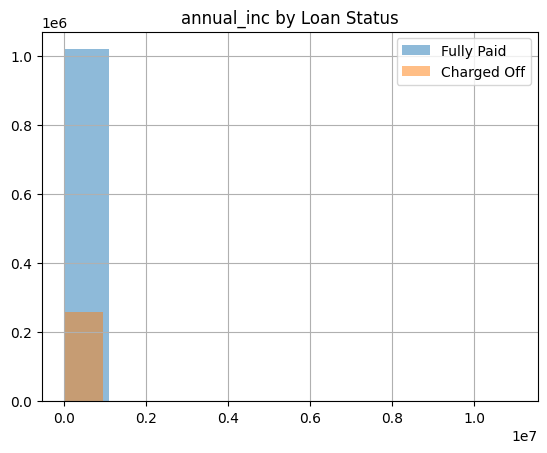

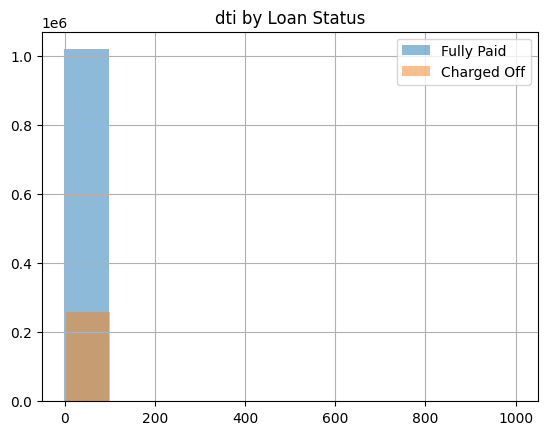

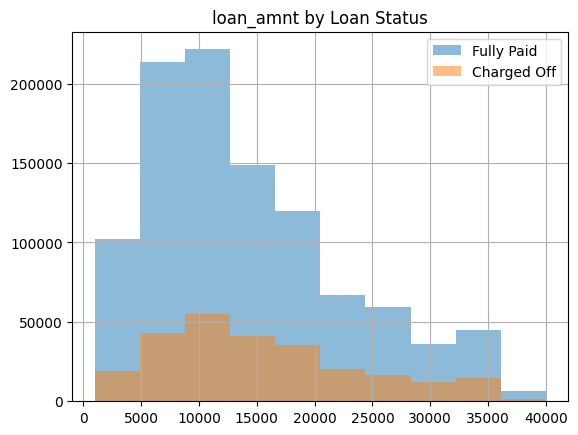

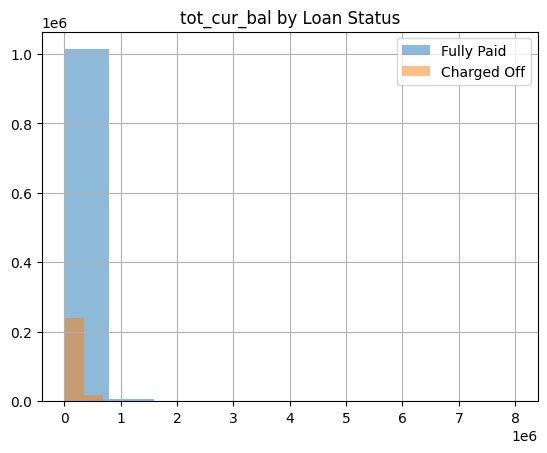

In [129]:
# So sánh từng feature giữa nhóm tốt (0) và xấu (1)
for col in numeric_cols:
    plt.figure()

    df[df["label"] == 0][col].hist(alpha=0.5, label="Fully Paid")
    df[df["label"] == 1][col].hist(alpha=0.5, label="Charged Off")

    plt.title(f"{col} by Loan Status")
    plt.legend()

    plt.show()

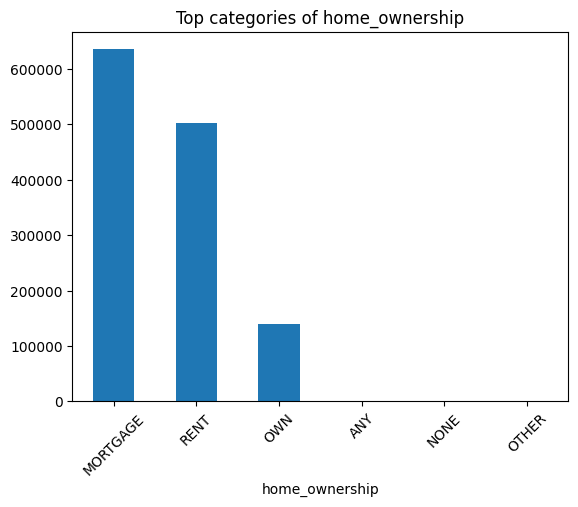

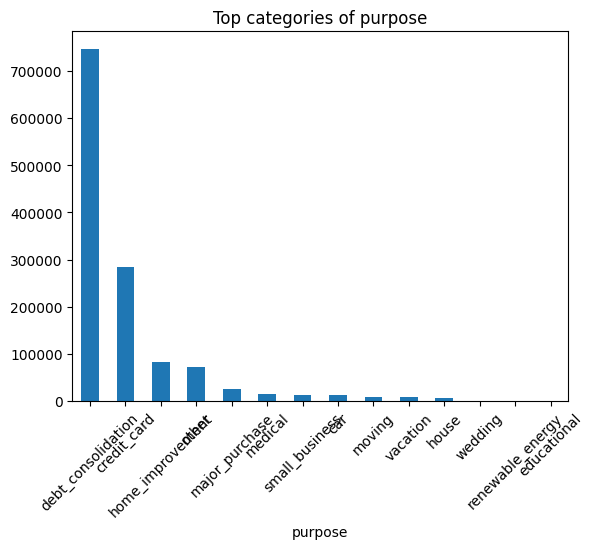

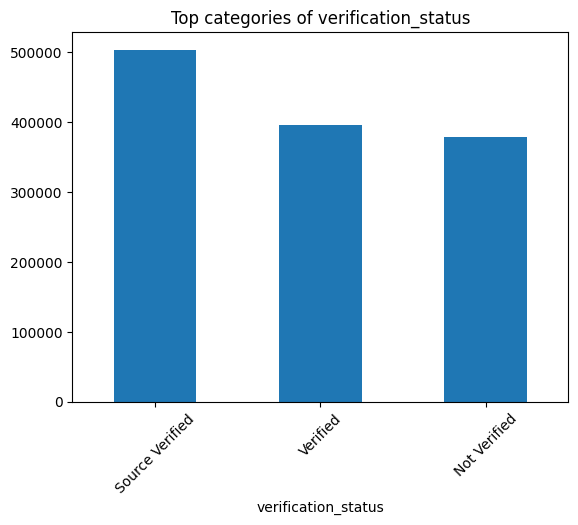

In [130]:
# Các biến phân loại
cat_cols = ["home_ownership", "purpose", "verification_status"]

# Vẽ top 10 category phổ biến
for col in cat_cols:
    plt.figure()

    df[col].value_counts().plot(kind="bar")

    plt.title(f"Top categories of {col}")
    plt.xticks(rotation=45)

    plt.show()

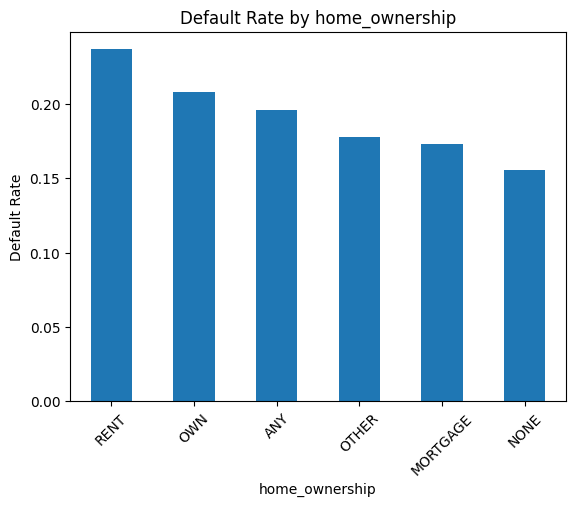

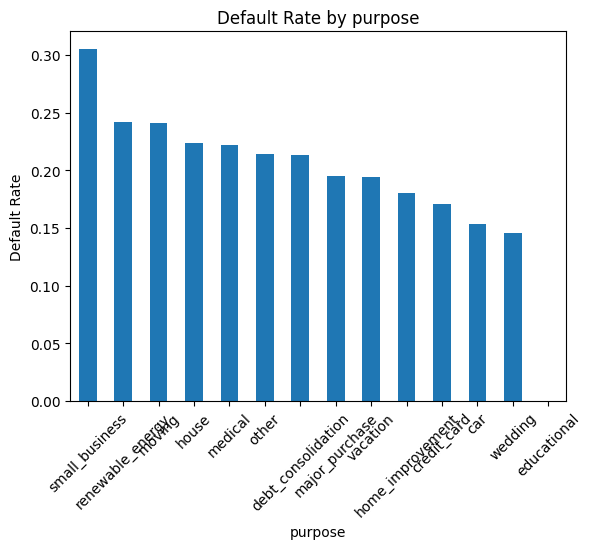

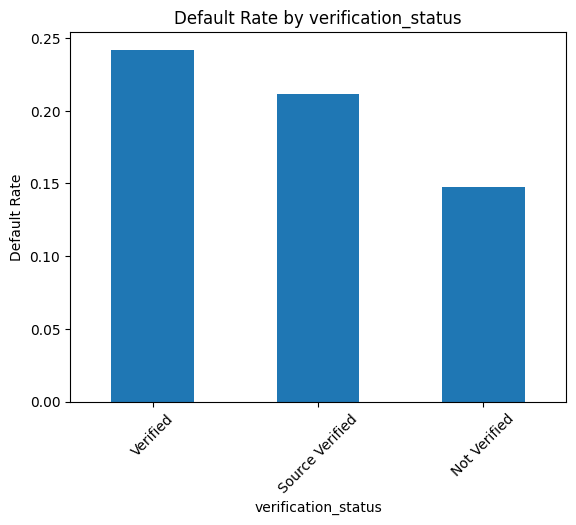

In [131]:
# Tính default rate (mean của label)
for col in cat_cols:
    plt.figure()

    default_rate = df.groupby(col)["label"].mean().sort_values(ascending=False)
    default_rate.plot(kind="bar")

    plt.title(f"Default Rate by {col}")
    plt.ylabel("Default Rate")
    plt.xticks(rotation=45)

    plt.show()

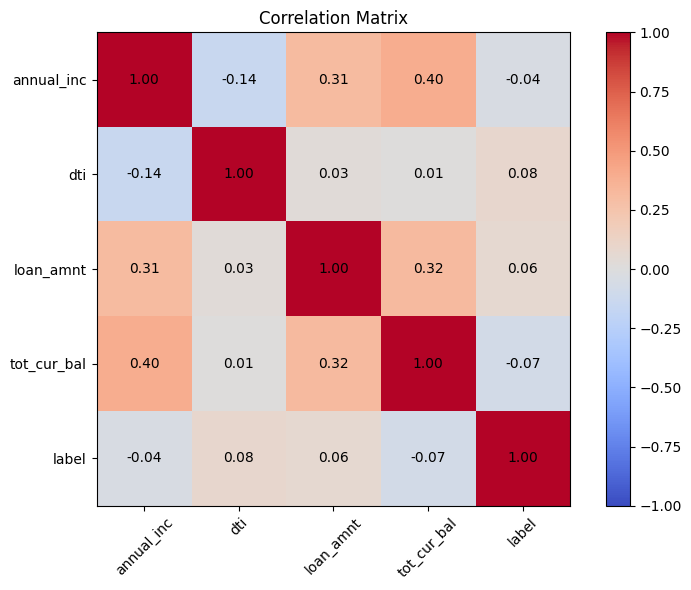

In [132]:
# Chọn các biến số để tính tương quan
corr_cols = ["annual_inc", "dti", "loan_amnt", "tot_cur_bal", "label"]

# Tính correlation
corr = df[corr_cols].corr()

# Vẽ heatmap
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Thêm chỉ số trên từng ô
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()